In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 第1版:無考慮 RSI
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 參數設定
file_path = '/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx'     # 請改成你的檔案路徑
output_path = '/content/drive/MyDrive/交易程式碼/交易紀錄.xlsx'  # 回測結果匯出路徑
initial_capital = 1_000_000  # 初始資金
stop_loss = 0.10            # 停損門檻 10%
take_profit = 0.20          # 停利門檻 20%

# 2. 讀取 Excel 並處理時間欄位
df = pd.read_excel(file_path)
df['年月日'] = pd.to_datetime(df['年月日'])
df.sort_values('年月日', inplace=True)
df.set_index('年月日', inplace=True)

# 標準化欄位名稱
for col in df.columns:
    if '開盤' in col:
        df['Open'] = df[col]
    if '收盤' in col:
        df['Close'] = df[col]

# 3. 計算技術指標
# MACD
df['EMA_fast'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_slow'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA_fast'] - df['EMA_slow']
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['signal_macd_buy']  = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
df['signal_macd_sell'] = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))


# 布林通道 (Bollinger Bands)
window = 20
df['MA20']    = df['Close'].rolling(window).mean()
df['STD20']   = df['Close'].rolling(window).std()

# 乖離率 (Divergence)
df['divergence']      = (df['Close'] - df['MA20']) / df['MA20']
df['signal_dev_buy']  = df['divergence'] < -0.05
df['signal_dev_sell'] = df['divergence'] >  0.05

# 4. 回測邏輯
cash = initial_capital
position = 0
entry_price = 0
trades = []

for date, row in df.iterrows():
    price = row['Close']
    # 買入條件：任何訊號為買
    if position == 0 and row[['signal_macd_buy','signal_dev_buy']].any():
        shares = cash // price
        if shares > 0:
            cost    = shares * price
            fee_buy = cost * 0.001425
            cash   -= (cost + fee_buy)
            position = shares
            entry_price = price
            trades.append({
                'action':'buy',
                'date': date,
                'price': price,
                'shares': shares,
                'fee_buy': fee_buy,
                'invested': cost + fee_buy,
                'cash_after': cash,
                'reason': 'MACD or Dev'
            })
    # 賣出條件：停損、停利或任何賣出訊號
    elif position > 0:
        pnl = (price - entry_price) / entry_price
        fee_sell = position * price * 0.001425
        tax      = position * price * 0.003
        if (pnl <= -stop_loss or pnl >= take_profit) or row[['signal_macd_sell','signal_dev_sell']].any():
            proceeds = position * price
            cash += (proceeds - fee_sell - tax)
            trades.append({
                'action':'sell',
                'date': date,
                'price': price,
                'shares': position,
                'fee_sell': fee_sell,
                'tax': tax,
                'proceeds': proceeds - fee_sell - tax,
                'return': pnl,
                'cash_after': cash
            })
            position = 0 # position = 0 → 空手（沒有部位）

# 5. 績效評估
trades_df = pd.DataFrame(trades)
if not trades_df.empty:
    final_value = cash + position * df['Close'].iloc[-1]
    total_return = final_value / initial_capital - 1
    days = (df.index[-1] - df.index[0]).days
    annual_return = (1 + total_return)**(365/days) - 1
    sell_returns = trades_df.query("action=='sell'")['return']
    win_rate = sell_returns.gt(0).mean()
    sharpe_ratio = sell_returns.mean() / sell_returns.std() * np.sqrt(252)
    print("===== 回測績效 =====")
    print(f"勝率:         {win_rate:.2%}")
    print(f"最終資產價值: NT${final_value:,.0f}")
    print(f"總報酬率:     {total_return:.2%}")
    print(f"年化報酬率:   {annual_return:.2%}")
    print(f"夏普比率:     {sharpe_ratio:.2f}")


===== 回測績效 =====
勝率:         52.83%
最終資產價值: NT$1,101,580
總報酬率:     10.16%
年化報酬率:   1.95%
夏普比率:     2.12


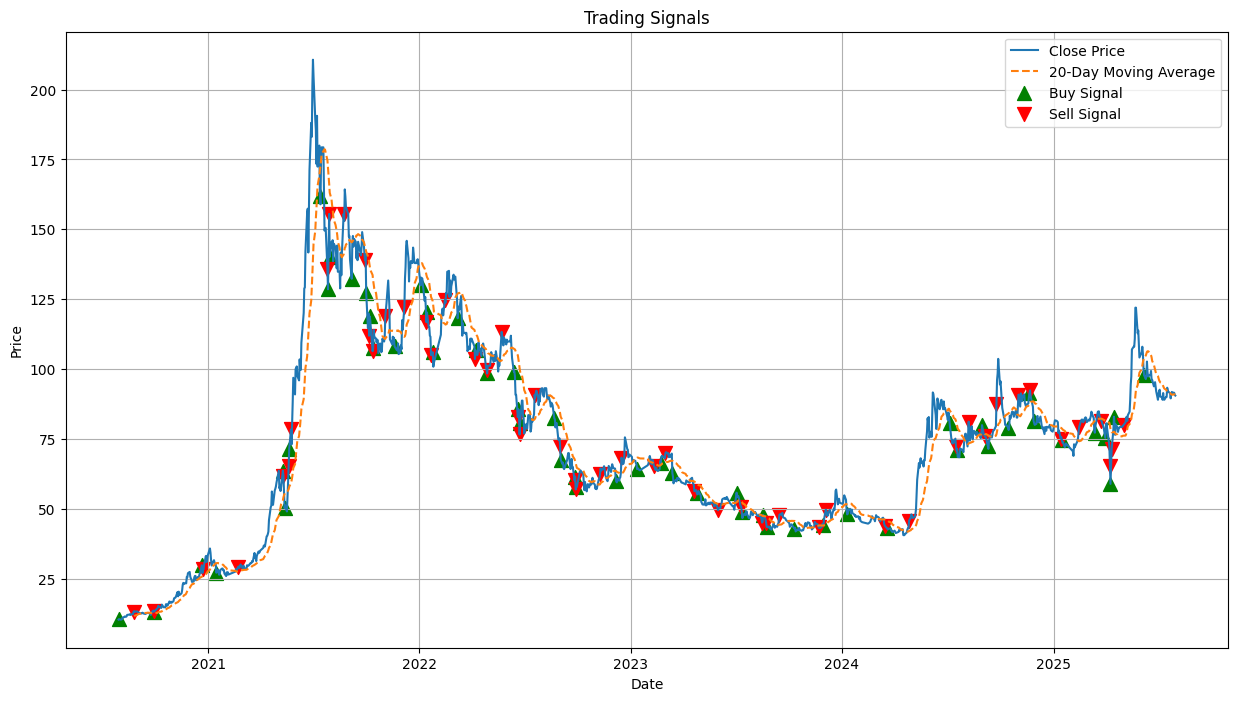

In [ ]:
# 6. 繪製交易訊號
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['MA20'], label='20-Day Moving Average', linestyle='--')

# 標示買入點
buy_signals = trades_df[trades_df['action'] == 'buy']
plt.scatter(buy_signals['date'], buy_signals['price'], marker='^', color='green', label='Buy Signal', s=100)

# 標示賣出點
sell_signals = trades_df[trades_df['action'] == 'sell']
plt.scatter(sell_signals['date'], sell_signals['price'], marker='v', color='red', label='Sell Signal', s=100)

plt.title('Trading Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

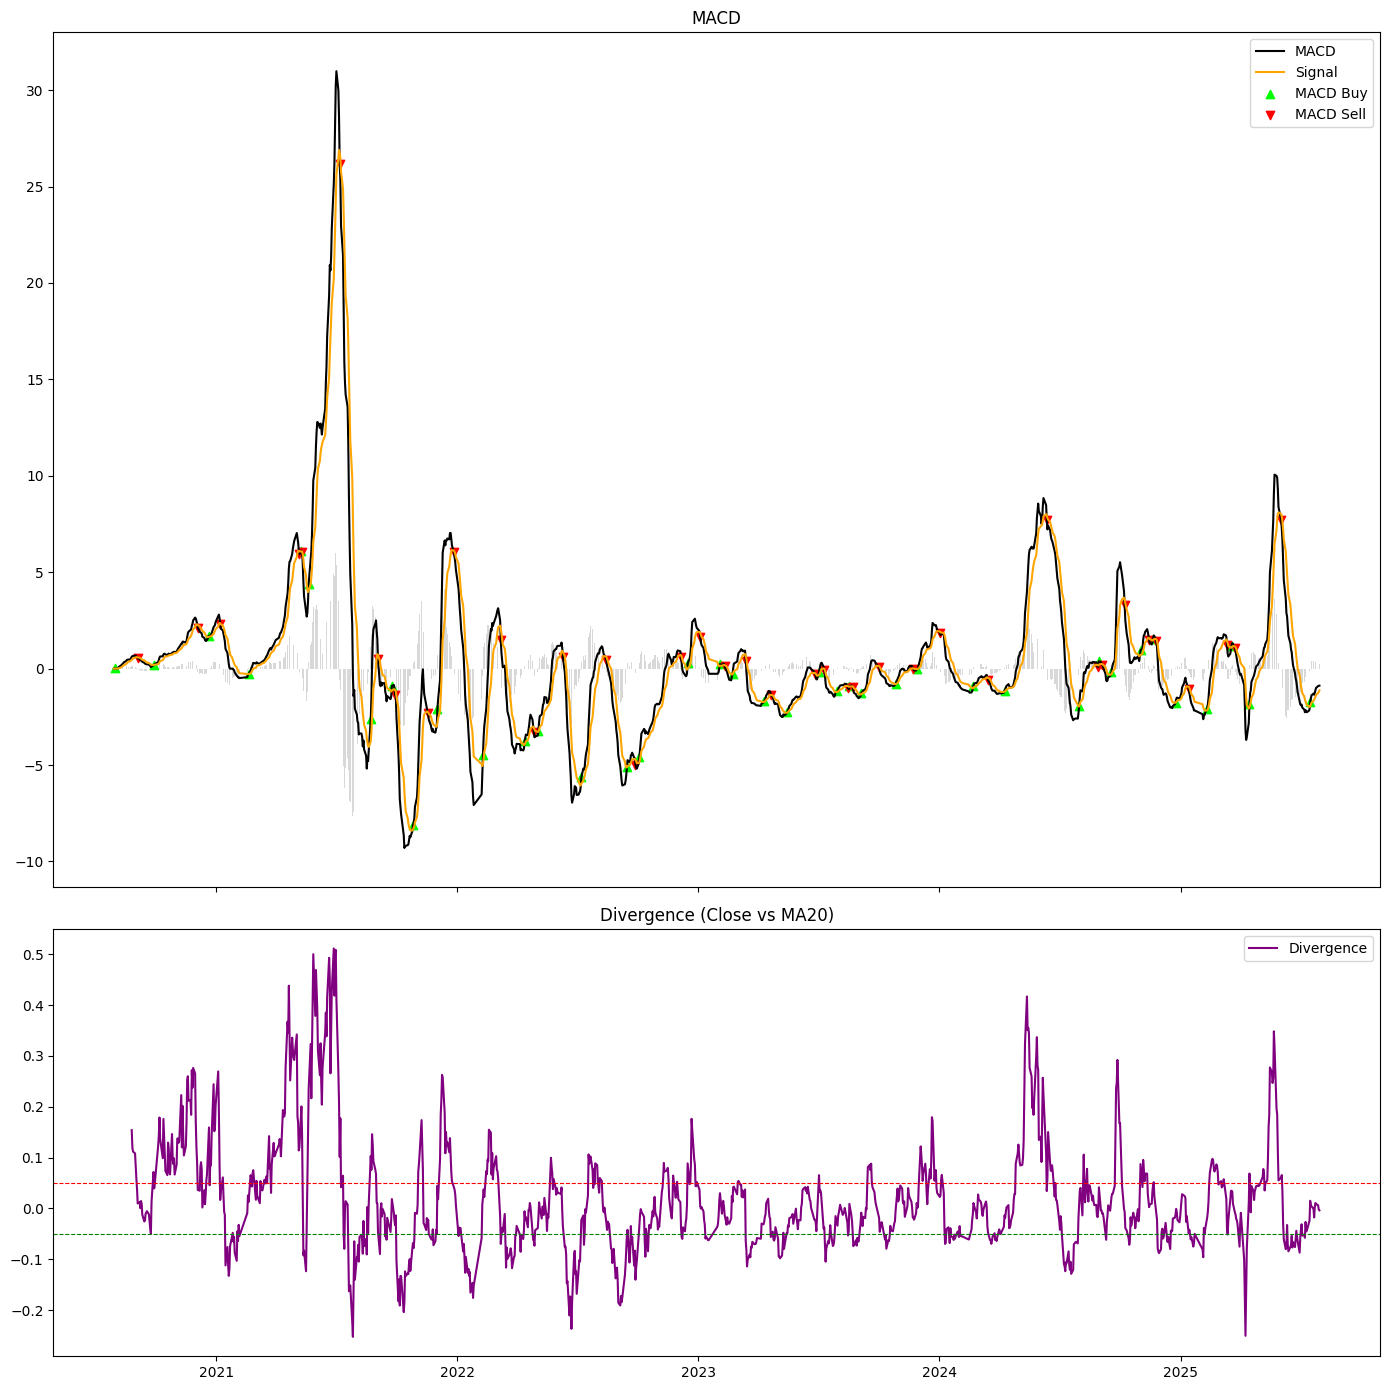

In [ ]:
file_path = '/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx'     # 請改成你的檔案路徑
output_path = '/content/drive/MyDrive/交易程式碼/交易紀錄.xlsx'

fig, axes = plt.subplots(2, 1, figsize=(14, 14), sharex=True,
                         gridspec_kw={'height_ratios':[2,1,]})

# MACD
ax = axes[0]
ax.bar(df.index, df['MACD'] - df['MACD_signal'], color='grey', alpha=0.3)
ax.plot(df.index, df['MACD'],      color='black', label='MACD')
ax.plot(df.index, df['MACD_signal'],  color='orange', label='Signal')
ax.scatter(df.index[df['signal_macd_buy']],  df['MACD'][df['signal_macd_buy']],  marker='^', color='lime', label='MACD Buy')
ax.scatter(df.index[df['signal_macd_sell']], df['MACD'][df['signal_macd_sell']], marker='v', color='red',  label='MACD Sell')
ax.set_title('MACD')
ax.legend()

# 乖離率
ax = axes[1]
ax.plot(df.index, df['divergence'], color='purple', label='Divergence')
ax.axhline(0.05,  color='red',  ls='--', lw=0.8)
ax.axhline(-0.05, color='green',ls='--', lw=0.8)
ax.set_title('Divergence (Close vs MA20)')
ax.legend()


plt.tight_layout()
plt.show()

======== 交易統計 ========
完成交易次數（Buy+Sell）: 76
平均損益率          : 0.95%
交易紀錄已匯出至 /content/drive/MyDrive/交易程式碼/交易紀錄.xlsx


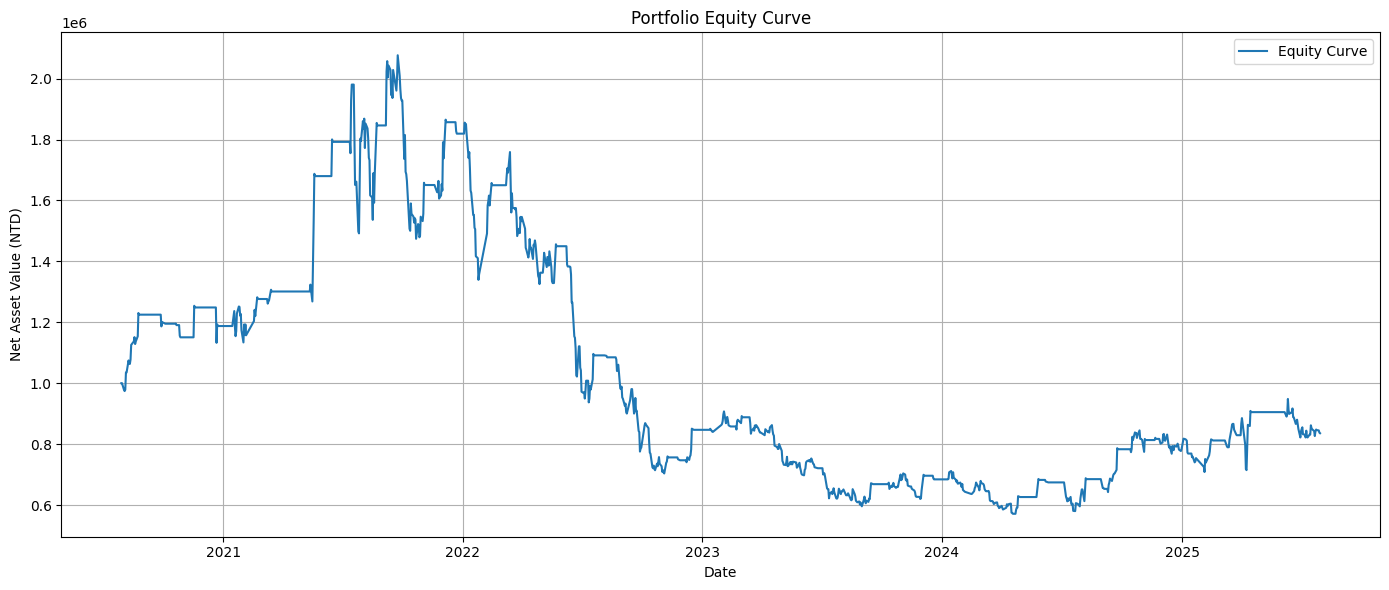

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 參數設定 -----------------------------------------------------------------
file_path   = '/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx'    # ← 改成你的檔案路徑
output_path = '/content/drive/MyDrive/交易程式碼/交易紀錄.xlsx'           # ← 匯出路徑
initial_capital = 1_000_000     # 初始資金
stop_loss   = 0.10              # 停損門檻
take_profit = 0.20
fast_len    = 9
slow_len    = 21
macd_len    = 5              # 停利門檻
buy_th      = -0.05 # Divergence buy threshold
sell_th     = 0.05 # Divergence sell threshold

# 2. 讀取 & 前處理 ------------------------------------------------------------
df = pd.read_excel(file_path)
df['年月日'] = pd.to_datetime(df['年月日'])
df.sort_values('年月日', inplace=True)
df.set_index('年月日', inplace=True)

# 標準化欄位名稱
for col in df.columns:
    if '開盤' in col:  df['Open']  = df[col]
    if '收盤' in col:  df['Close'] = df[col]

# 3. 技術指標 -----------------------------------------------------------------
# MACD
df['EMA_fast']    = df['Close'].ewm(span=fast_len, adjust=False).mean()
df['EMA_slow']    = df['Close'].ewm(span=slow_len, adjust=False).mean()
df['MACD']        = df['EMA_fast'] - df['EMA_slow']
df['MACD_signal'] = df['MACD'].ewm(span=macd_len, adjust=False).mean()
df['signal_macd_buy']  = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
df['signal_macd_sell'] = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))

# 布林通道 + 乖離率
window = 20
df['MA20']      = df['Close'].rolling(window).mean()
df['STD20']     = df['Close'].rolling(window).std()
df['divergence']      = (df['Close'] - df['MA20']) / df['MA20']
df['signal_dev_buy']  = df['divergence'] < buy_th
df['signal_dev_sell'] = df['divergence'] > sell_th

# 4. 回測主迴圈 ---------------------------------------------------------------
cash = initial_capital
position = 0
entry_price = 0
trades = []            # 原始買 / 賣動作
equity_curve = []      # === NEW === 用來存每天的資產淨值

for date, row in df.iterrows():
    price = row['Close']
    # 先記錄「當下」資產淨值
    equity_curve.append({'date': date, 'equity': cash + position * price})  # === NEW ===

    # ─── 買入 ───
    if position == 0 and row[['signal_macd_buy', 'signal_dev_buy']].any():
        shares = cash // price
        if shares > 0:
            cost     = shares * price
            fee_buy  = cost * 0.001425
            cash    -= (cost + fee_buy)
            position = shares
            entry_price = price
            trades.append({
                'action':'buy', 'date': date, 'price': price, 'shares': shares,
                'fee': fee_buy, 'cash_after': cash, 'reason': 'MACD or Dev'
            })

    # ─── 賣出 ───
    elif position > 0:
        pnl = (price - entry_price) / entry_price
        fee_sell = position * price * 0.001425
        tax      = position * price * 0.003
        if (pnl <= -stop_loss or pnl >= take_profit) or row[['signal_macd_sell','signal_dev_sell']].any():
            proceeds = position * price
            cash += (proceeds - fee_sell - tax)
            trades.append({
                'action':'sell', 'date': date, 'price': price, 'shares': position,
                'fee': fee_sell + tax, 'pnl%': pnl, 'cash_after': cash
            })
            position = 0   # 平倉

# 5. 將原始動作轉成「一次交易」記錄 ------------------------------------------
trades_df = pd.DataFrame(trades)

# === NEW === 把 buy / sell 配對
completed = []
current   = {}
for _, row in trades_df.iterrows():
    if row['action'] == 'buy':
        current = row.to_dict()
    else:  # sell
        completed.append({
            'buy_date' : current['date'],
            'buy_price': current['price'],
            'sell_date': row['date'],
            'sell_price': row['price'],
            'shares'   : row['shares'],
            'holding_days': (row['date'] - current['date']).days,
            'pnl%'     : row['pnl%']
        })
        current = {}
completed_df = pd.DataFrame(completed)
total_trades = len(completed_df)   # 一買一賣才算一次

print(f'======== 交易統計 ========')
print(f'完成交易次數（Buy+Sell）: {total_trades}')
if not completed_df.empty:
    print(f'平均損益率          : {completed_df["pnl%"].mean():.2%}')

# 6. 產出 Excel ---------------------------------------------------------------
# === NEW === 兩個工作表：RawActions 與 CompletedTrades
with pd.ExcelWriter(output_path) as writer:
    trades_df.to_excel(writer,    sheet_name='RawActions',      index=False)
    completed_df.to_excel(writer, sheet_name='CompletedTrades', index=False)
print(f'交易紀錄已匯出至 {output_path}')

# 7. 繪製資產淨值變化曲線 ------------------------------------------------------
equity_df = pd.DataFrame(equity_curve).set_index('date')
plt.figure(figsize=(14,6))
plt.plot(equity_df.index, equity_df['equity'], label='Equity Curve')
plt.title('Portfolio Equity Curve')               # === NEW === Title
plt.xlabel('Date')
plt.ylabel('Net Asset Value (NTD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. （選擇性）若仍想看買賣點，可沿用舊版 plot -----------------------------
# 若要顯示買賣點，可把原本的「Close + MA20 + Buy/Sell scatter」區塊保留

In [ ]:
trades_df.to_csv("/content/drive/MyDrive/交易程式碼/2025萬海回測結果第一版交易紀錄.csv")

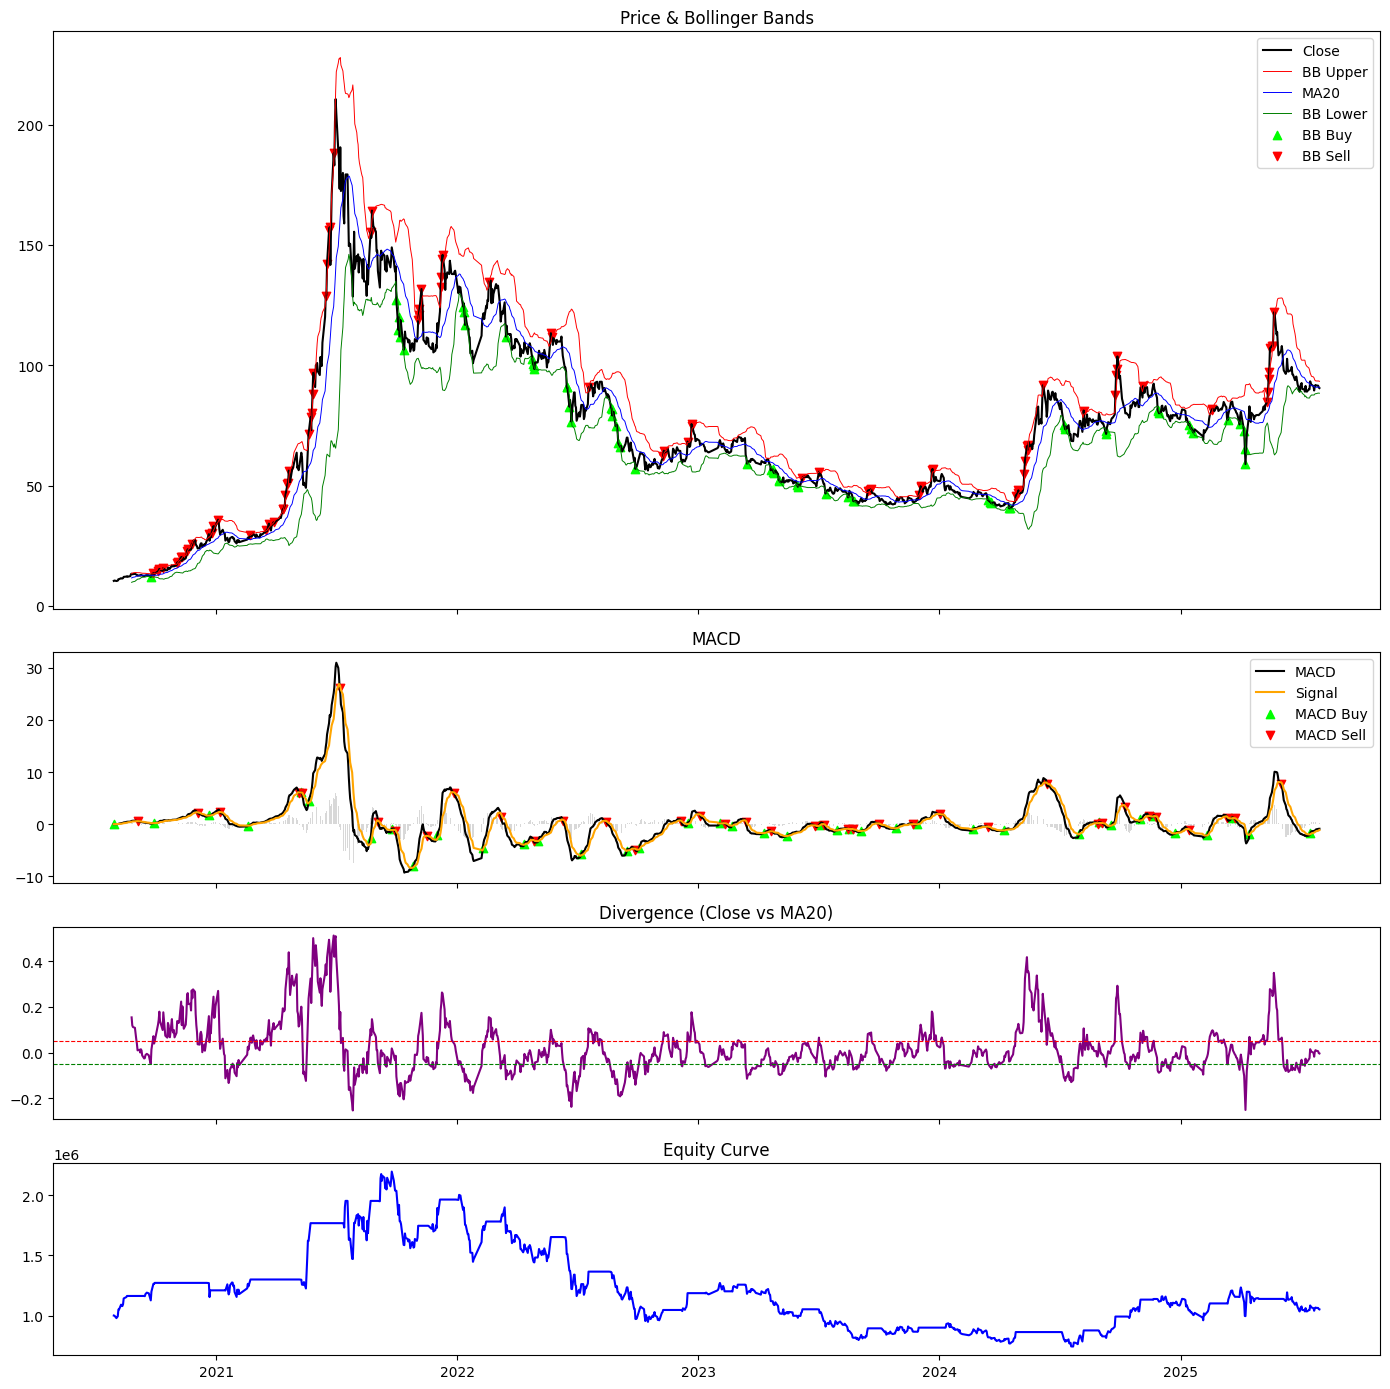


===== PERFORMANCE =====
初始資金:   NT$1,000,000
最終資產:   NT$1,051,295
總報酬率:   5.13%
年化報酬率: 1.00%
夏普比率:   0.21
勝率:       52.73%


In [ ]:
# 第2版:有考慮 RSI
import pandas as pd # 載入 Pandas，用來讀取 Excel 及表格運算；習慣用 pd 當縮寫。
import numpy as np # NumPy，做數學運算（陣列、平均、標準差…）。
import matplotlib.pyplot as plt # Matplotlib 畫圖工具，plt 為常用縮寫。
from pathlib import Path # Path 用來檢查檔案 / 目錄是否存在，跨平台比 os.path 好用。

# ========== 參數 ==========
file_path  = '/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx'
output_path = '/content/drive/MyDrive/交易程式碼/交易紀錄.xlsx'

initial_capital = 1_000_000
stop_loss   = 0.10     # 10 % 停損
take_profit = 0.20     # 20 % 停利
fee_rate    = 0.001425 # 單邊手續費率
tax_rate    = 0.003    # 賣出證交稅率

buy_mode  = 'any'  # 'all' or 'any'全部都成立 (all) 還是 任一成立 (any)。
sell_mode = 'any'

# TRUE = 啟用該訊號　True = 用來判斷進出場；False = 忽略該指標。
signal_flags = dict(
    bb   = True,   # 布林通道
    macd = True,
    div  = True,
    rsi  = True
)

# ========== 1. 讀檔與前處理 ==========
# 路徑檢查，檔案不存在就丟錯；避免程式靜靜失敗。
if not Path(file_path).exists():
    raise FileNotFoundError(file_path)

df = pd.read_excel(file_path) # 把 Excel 讀成 DataFrame
df['年月日'] = pd.to_datetime(df['年月日']) # 把「年月日」字串轉成真正日期
df.sort_values('年月日', inplace=True) # 依日期由舊到新排序，確保時間序列正確。
df.set_index('年月日', inplace=True) # 把日期設為索引，後面用 df.index 直接取日期。

open_col  = [c for c in df.columns if '開盤' in c][0] # 自動找列名含「開盤」「收盤」的欄；不同來源欄名可能略有差。
close_col = [c for c in df.columns if '收盤' in c][0] # 統一欄位名稱，之後計算指標時不用管原欄名。
df['Open']  = df[open_col]
df['Close'] = df[close_col]

# ========== 2. 技術指標 ==========
# 2-1 Bollinger
win = 20
df['MA20']     = df['Close'].rolling(win).mean() # 規定 20 日視窗。
df['STD20']    = df['Close'].rolling(win).std() # 20 日移動平均。
df['BB_upper'] = df['MA20'] + 2*df['STD20'] # 20 日標準差。
df['BB_lower'] = df['MA20'] - 2*df['STD20'] # 上軌 = MA + 2σ、下軌 = MA − 2σ。
df['sig_bb_buy']  = df['Close'] < df['BB_lower'] # 收盤價 < 下軌 → 買；> 上軌 → 賣。
df['sig_bb_sell'] = df['Close'] > df['BB_upper']

# 2-2 MACD
df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean() # 12、26 日指數移動平均 (EMA)。
df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD']  = df['EMA12'] - df['EMA26'] # 快線 − 慢線。
df['MACD_sig'] = df['MACD'].ewm(span=9, adjust=False).mean() # 9 日 EMA 作訊號線。
df['sig_macd_buy']  = (df['MACD'] > df['MACD_sig']) & (df['MACD'].shift(1) <= df['MACD_sig'].shift(1)) # 當天快線 > 訊號線 且 昨天快線 ≤ 訊號線 → 黃金交叉（買）。
df['sig_macd_sell'] = (df['MACD'] < df['MACD_sig']) & (df['MACD'].shift(1) >= df['MACD_sig'].shift(1)) # 反向：死亡交叉（賣）。


# 2-3 Divergence
df['DIV']         = (df['Close'] - df['MA20']) / df['MA20'] # (Close - MA20)/MA20 → ±% 距離。
# < −5 % 買、> +5 % 賣。數字可自己改。
df['sig_div_buy']  = df['DIV'] < -0.05
df['sig_div_sell'] = df['DIV'] >  0.05

# 2-4 RSI
rsi_period = 14 # rsi_period = 14（經典設定）。
chg  = df['Close'].diff() # 拆漲跌點數，分別 rolling 平均。
gain = chg.clip(lower=0)
loss = -chg.clip(upper=0)
rs = gain.rolling(rsi_period).mean() / loss.rolling(rsi_period).mean() # RSI 公式。
df['RSI'] = 100 - 100/(1+rs) # RSI < 30 超賣=買；> 70 超買=賣。
df['sig_rsi_buy']  = df['RSI'] < 30
df['sig_rsi_sell'] = df['RSI'] > 70

# ========== 3. 回測 ==========
cash, shares, entry_px = initial_capital, 0, 0 # cash=本金、shares=持股股數、entry_px=建倉價、equity_curve=資產曲線 list、trades=交易紀錄。
equity_curve, trades = [], []

# 幫助依設定篩選訊號
# _active()	小工具：判斷此訊號是否被 signal_flags 開啟。
def _active(col_name):
    flag_key = col_name.split('_')[1]   # e.g. sig_bb_buy → bb
    return signal_flags.get(flag_key, False)

# buy_cols / sell_cols	把所有 sig_xx_buy 但有啟用的欄名列出，後面方便向量化判斷。
buy_cols  = [c for c in df.columns if c.startswith('sig_') and c.endswith('_buy')  and _active(c)]
sell_cols = [c for c in df.columns if c.startswith('sig_') and c.endswith('_sell') and _active(c)]

# 每天跑一次邏輯：
# 1. 先判斷買訊 (buy_signal)
# 2. 再判斷賣訊 + 停損停利 (sell_signal + hit_sl_tp)
for date, row in df.iterrows():
    price = row['Close']

    buy_signal  = row[buy_cols].all()  if buy_mode  == 'all'  else row[buy_cols].any()
    sell_signal = row[sell_cols].all() if sell_mode == 'all' else row[sell_cols].any()

    # --------- 進場 ---------
    # 沒持股 (shares==0) 且買訊成立 → 全部現金買股
    # 1.股數整張取整數 cash//price
    # 2.扣手續費 cost*fee_rate
    if shares == 0 and buy_signal:
        shares = cash // price
        if shares:
            cost = shares * price
            fee  = cost * fee_rate
            cash -= cost + fee
            entry_px = price
            trades.append(dict(Date=date, Action='BUY', Price=price, Shares=shares,
                               Fee=fee, Cash=cash, Reason='buy_signal'))
    # --------- 出場 ---------
    # 有持股且 (賣訊 or 停損/停利) → 全部賣
    # 1.收手續費 + 證交稅
    # 2.把賣出淨額加回現金
    elif shares:
        pnl_pct = (price - entry_px) / entry_px
        hit_sl_tp = pnl_pct <= -stop_loss or pnl_pct >= take_profit

        if sell_signal or hit_sl_tp:
            proceeds = shares * price
            fee = proceeds * fee_rate
            tax = proceeds * tax_rate
            cash += proceeds - fee - tax
            trades.append(dict(Date=date, Action='SELL', Price=price, Shares=shares,
                               Fee=fee, Tax=tax, ReturnPct=pnl_pct, Cash=cash,
                               Reason='SL/TP' if hit_sl_tp else 'sell_signal'))
            shares = 0
    # 每天把 cash + 持股市值 存到 equity_curve，最後塞回 df['Equity']。
    equity_curve.append(cash + shares * price)

df['Equity'] = equity_curve

# ========== 4. 繪圖 ==========
# 4×1 子圖（共用 X 軸）：
# 1.收盤 + 布林通道 + 買賣點
# 2.MACD (柱狀圖 + 快/慢線 + 買賣點)
# 3.乖離率折線（±5 % 參考線）
# 4.資產淨值曲線
fig, axes = plt.subplots(4, 1, figsize=(14, 14),
                         gridspec_kw={'height_ratios':[3,1.2,1,1]}, sharex=True)

# 4-1 Price + BB
ax = axes[0]
ax.plot(df.index, df['Close'], color='black', label='Close')
ax.plot(df.index, df['BB_upper'], color='red', lw=0.7, label='BB Upper')
ax.plot(df.index, df['MA20'],     color='blue', lw=0.7, label='MA20')
ax.plot(df.index, df['BB_lower'], color='green', lw=0.7, label='BB Lower')
ax.scatter(df.index[df['sig_bb_buy']],  df['Close'][df['sig_bb_buy']],  marker='^', color='lime', label='BB Buy')
ax.scatter(df.index[df['sig_bb_sell']], df['Close'][df['sig_bb_sell']], marker='v', color='red', label='BB Sell')
ax.set_title('Price & Bollinger Bands')
ax.legend()

# 4-2 MACD
ax = axes[1]
ax.bar(df.index, df['MACD'] - df['MACD_sig'], color='grey', alpha=0.3)
ax.plot(df.index, df['MACD'],      color='black', label='MACD')
ax.plot(df.index, df['MACD_sig'],  color='orange', label='Signal')
ax.scatter(df.index[df['sig_macd_buy']],  df['MACD'][df['sig_macd_buy']],  marker='^', color='lime', label='MACD Buy')
ax.scatter(df.index[df['sig_macd_sell']], df['MACD'][df['sig_macd_sell']], marker='v', color='red',  label='MACD Sell')
ax.set_title('MACD')
ax.legend()

# 4-3 Divergence
ax = axes[2]
ax.plot(df.index, df['DIV'], color='purple')
ax.axhline(0.05,  color='red', ls='--', lw=0.8)
ax.axhline(-0.05, color='green', ls='--', lw=0.8)
ax.set_title('Divergence (Close vs MA20)')

# 4-4 Equity Curve
ax = axes[3]
ax.plot(df.index, df['Equity'], color='blue')
ax.set_title('Equity Curve')

plt.tight_layout()
plt.show()

# ========== 5. 績效 ==========
trades_df = pd.DataFrame(trades)
if not trades_df.empty:
    final_value = df['Equity'].iloc[-1] # final_value: 最終現金 + 未平倉市值 (此腳本通常已平倉)。
    tot_ret = final_value / initial_capital - 1 # tot_ret:	總報酬率。
    days = (df.index[-1] - df.index[0]).days
    ann_ret = (1 + tot_ret)**(365/days) - 1 # ann_ret	年化報酬：(1+R)^365/天數 −1。
    daily_ret = df['Equity'].pct_change().dropna()
    sharpe = daily_ret.mean() / daily_ret.std() * np.sqrt(252) # sharpe:用每日資產報酬 daily_ret 計算，年化因子 252（交易日）。
    # win_rate:出清交易中，獲利筆數 / 總筆數。
    win_rate = trades_df.query("Action=='SELL' & ReturnPct>0").shape[0] /\
               trades_df.query("Action=='SELL'").shape[0]

    print('\n===== PERFORMANCE =====')
    print(f'初始資金:   NT${initial_capital:,.0f}')
    print(f'最終資產:   NT${final_value:,.0f}')
    print(f'總報酬率:   {tot_ret:.2%}')
    print(f'年化報酬率: {ann_ret:.2%}')
    print(f'夏普比率:   {sharpe:.2f}')
    print(f'勝率:       {win_rate:.2%}')

# 若要存交易紀錄：取消最下方 to_excel() 的註解即可。
# trades_df.to_excel(output_path, index=False)

In [ ]:
trades_df.to_csv("/content/drive/MyDrive/交易程式碼/20250801萬海回測結果.csv")

買進 20000 股，剩餘現金 0
賣出 20000 股，回收 1,200,000 元，最終現金 1,200,000
===== 回測績效 =====
勝率:         52.83%
最終資產價值: NT$1,101,580
總報酬率:     10.16%
年化報酬率:   1.95%
夏普比率:     2.12


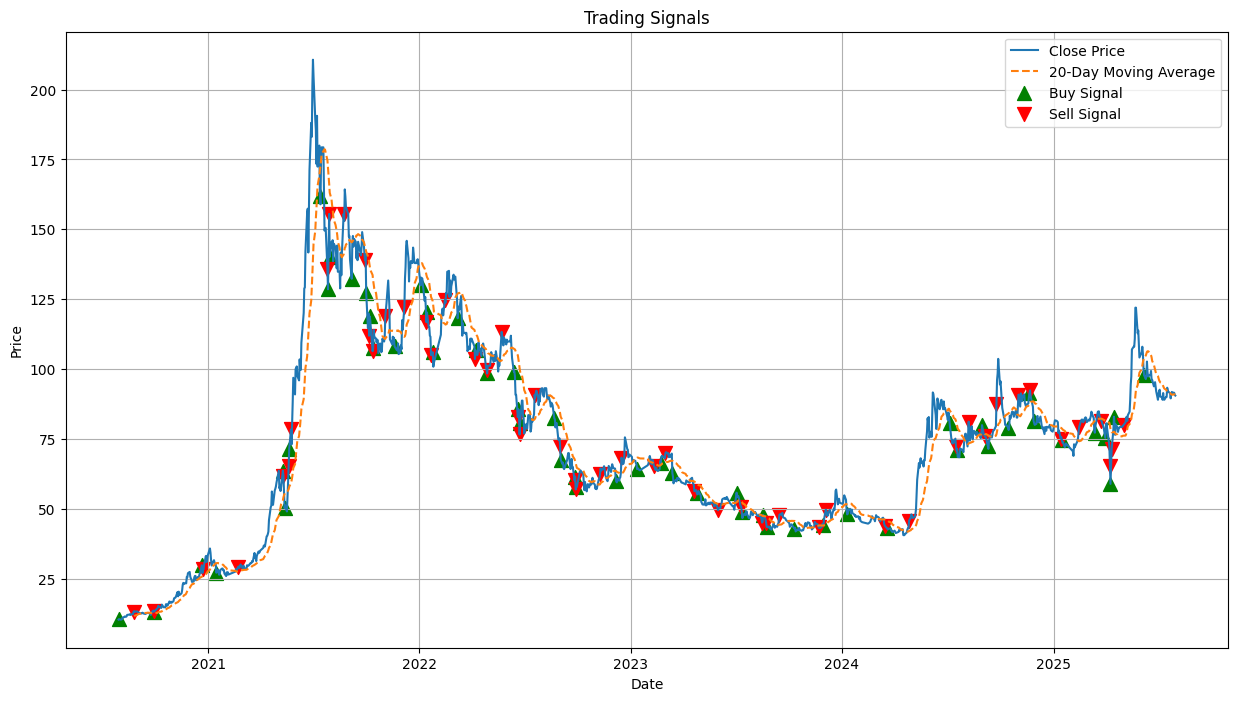

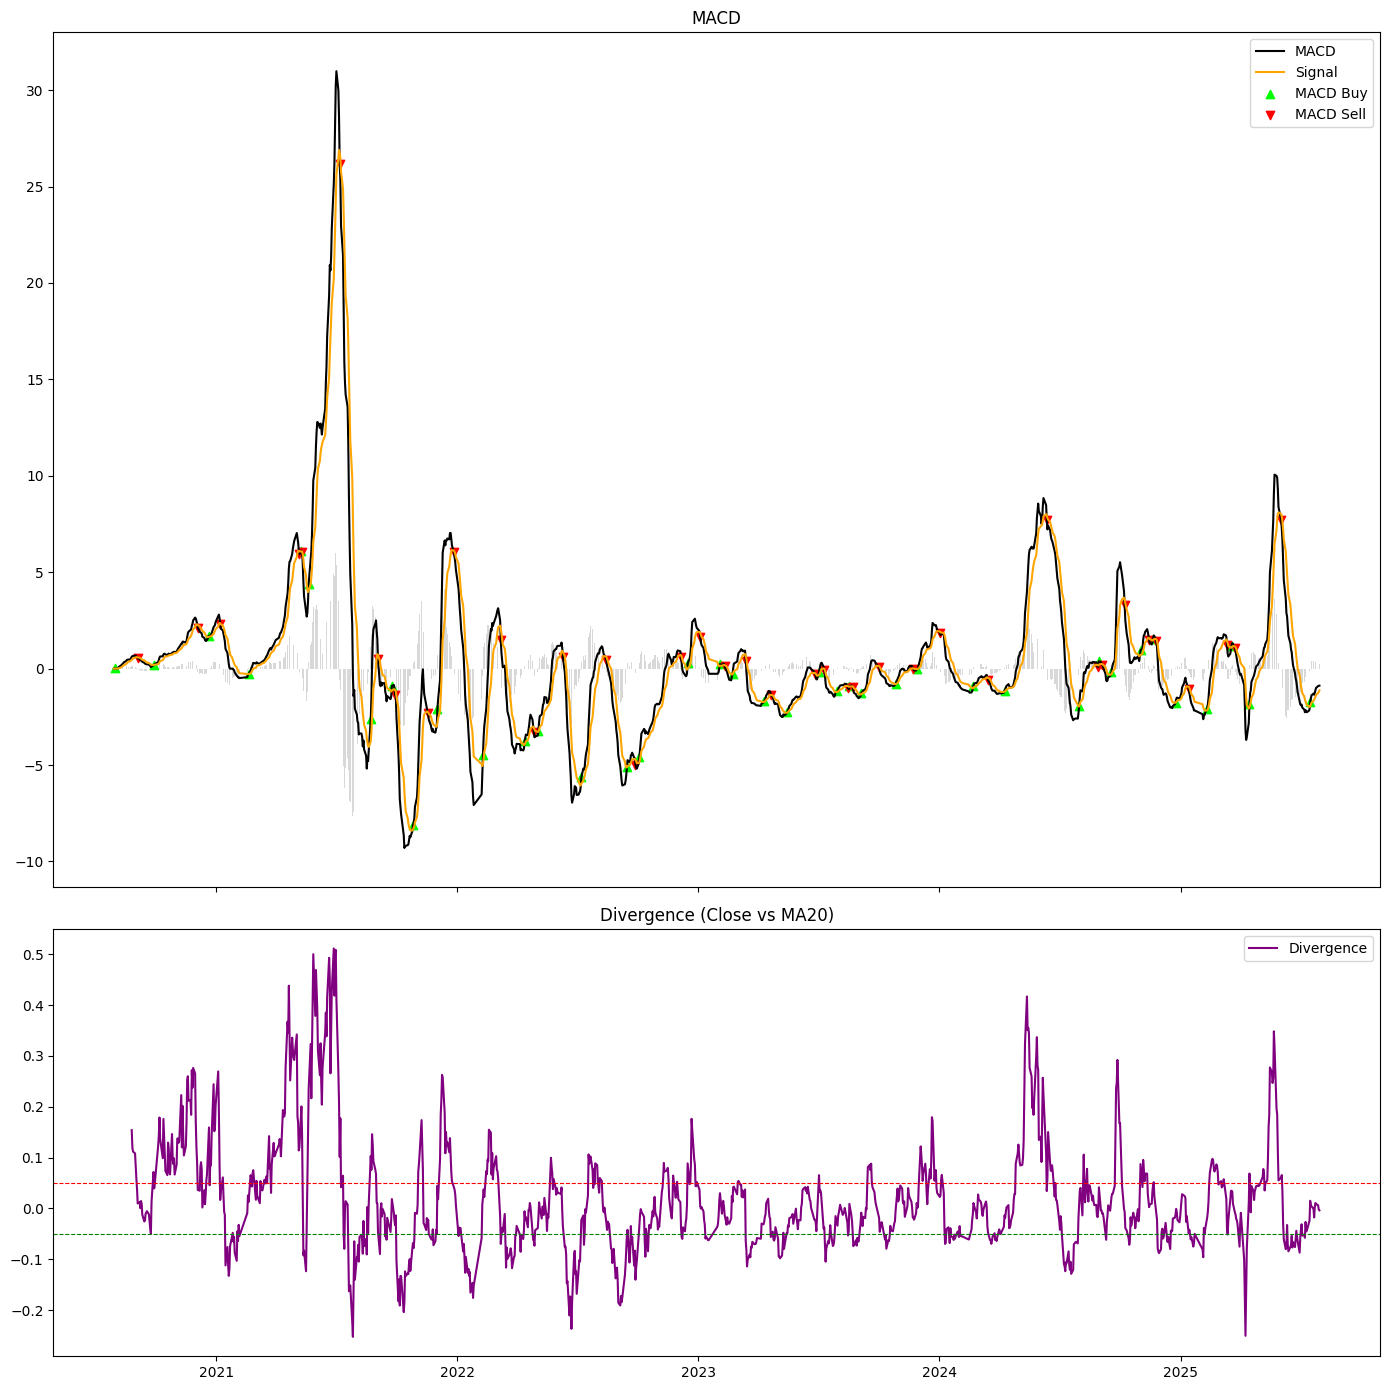

In [ ]:
# 第3版：無RSI，修改變數
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 參數設定
file_path = '/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx'     # 請改成你的檔案路徑
output_path = '/content/drive/MyDrive/交易程式碼/交易紀錄.xlsx'  # 回測結果匯出路徑
initial_capital = 1_000_000  # 初始資金
stop_loss = 0.05            # 停損門檻
take_profit = 0.30          # 停利門檻

# 2. 讀取 Excel 並處理時間欄位
df = pd.read_excel(file_path)
df['年月日'] = pd.to_datetime(df['年月日'])
df.sort_values('年月日', inplace=True)
df.set_index('年月日', inplace=True)

# 標準化欄位名稱
for col in df.columns:
    if '開盤' in col:
        df['Open'] = df[col]
    if '收盤' in col:
        df['Close'] = df[col]

# 3. 計算技術指標
# MACD
df['EMA_fast'] = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_slow'] = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = df['EMA_fast'] - df['EMA_slow']
df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['signal_macd_buy']  = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
df['signal_macd_sell'] = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))


# 布林通道 (Bollinger Bands)
window = 20
df['MA20']    = df['Close'].rolling(window).mean()
df['STD20']   = df['Close'].rolling(window).std()

# 乖離率 (Divergence)
df['divergence']      = (df['Close'] - df['MA20']) / df['MA20']
df['signal_dev_buy']  = df['divergence'] < -0.05
df['signal_dev_sell'] = df['divergence'] >  0.05

# 4. 回測邏輯
cash = initial_capital
position = 0
entry_price = 0
trades = []

for date, row in df.iterrows():
    price = row['Close']
    # 買入條件：任何訊號為買
    if position == 0 and row[['signal_macd_buy','signal_dev_buy']].any():
        shares = cash // price
        if shares > 0:
            cost    = shares * price
            fee_buy = cost * 0.001425
            cash   -= (cost + fee_buy)
            position = shares
            entry_price = price
            trades.append({
                'action':'buy',
                'date': date,
                'price': price,
                'shares': shares,
                'fee_buy': fee_buy,
                'invested': cost + fee_buy,
                'cash_after': cash,
                'reason': 'MACD or Dev'
            })
    # 賣出條件：停損、停利或任何賣出訊號
    elif position > 0:
        pnl = (price - entry_price) / entry_price
        fee_sell = position * price * 0.001425
        tax      = position * price * 0.003
        if (pnl <= -stop_loss or pnl >= take_profit) or row[['signal_macd_sell','signal_dev_sell']].any():
            proceeds = position * price
            cash += (proceeds - fee_sell - tax)
            trades.append({
                'action':'sell',
                'date': date,
                'price': price,
                'shares': position,
                'fee_sell': fee_sell,
                'tax': tax,
                'proceeds': proceeds - fee_sell - tax,
                'return': pnl,
                'cash_after': cash
            })
            position = 0 # position = 0 → 空手（沒有部位）

# 5. 績效評估
trades_df = pd.DataFrame(trades)
if not trades_df.empty:
    final_value = cash + position * df['Close'].iloc[-1]
    total_return = final_value / initial_capital - 1
    days = (df.index[-1] - df.index[0]).days
    annual_return = (1 + total_return)**(365/days) - 1
    sell_returns = trades_df.query("action=='sell'")['return']
    win_rate = sell_returns.gt(0).mean()
    sharpe_ratio = sell_returns.mean() / sell_returns.std() * np.sqrt(252)
    print("===== 回測績效 =====")
    print(f"勝率:         {win_rate:.2%}")
    print(f"最終資產價值: NT${final_value:,.0f}")
    print(f"總報酬率:     {total_return:.2%}")
    print(f"年化報酬率:   {annual_return:.2%}")
    print(f"夏普比率:     {sharpe_ratio:.2f}")

# 6. 繪製交易訊號
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['MA20'], label='20-Day Moving Average', linestyle='--')

# 標示買入點
buy_signals = trades_df[trades_df['action'] == 'buy']
plt.scatter(buy_signals['date'], buy_signals['price'], marker='^', color='green', label='Buy Signal', s=100)

# 標示賣出點
sell_signals = trades_df[trades_df['action'] == 'sell']
plt.scatter(sell_signals['date'], sell_signals['price'], marker='v', color='red', label='Sell Signal', s=100)

plt.title('Trading Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

file_path = '/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx'     # 請改成你的檔案路徑
output_path = '/content/drive/MyDrive/交易程式碼/交易紀錄.xlsx'

fig, axes = plt.subplots(2, 1, figsize=(14, 14), sharex=True,
                         gridspec_kw={'height_ratios':[2,1,]})

# MACD
ax = axes[0]
ax.bar(df.index, df['MACD'] - df['MACD_signal'], color='grey', alpha=0.3)
ax.plot(df.index, df['MACD'],      color='black', label='MACD')
ax.plot(df.index, df['MACD_signal'],  color='orange', label='Signal')
ax.scatter(df.index[df['signal_macd_buy']],  df['MACD'][df['signal_macd_buy']],  marker='^', color='lime', label='MACD Buy')
ax.scatter(df.index[df['signal_macd_sell']], df['MACD'][df['signal_macd_sell']], marker='v', color='red',  label='MACD Sell')
ax.set_title('MACD')
ax.legend()

# 乖離率
ax = axes[1]
ax.plot(df.index, df['divergence'], color='purple', label='Divergence')
ax.axhline(0.05,  color='red',  ls='--', lw=0.8)
ax.axhline(-0.05, color='green',ls='--', lw=0.8)
ax.set_title('Divergence (Close vs MA20)')
ax.legend()


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# === 回測函式 ===
def backtest_macd(df, fast_len=12, slow_len=26, macd_len=9,
                  stop_loss_pct=0.1, take_profit_pct=0.2,
                  fee_rate=0.001425, tax_rate=0.003):

    data = df.copy()

    # 計算 MACD 指標
    data['EMA_fast'] = data['Close'].ewm(span=fast_len, adjust=False).mean()
    data['EMA_slow'] = data['Close'].ewm(span=slow_len, adjust=False).mean()
    data['MACD'] = data['EMA_fast'] - data['EMA_slow']
    data['MACD_signal'] = data['MACD'].ewm(span=macd_len, adjust=False).mean()
    data['Hist'] = data['MACD'] - data['MACD_signal']

    # 訊號判斷
    data['golden_cross'] = (data['Hist'] > 0) & (data['Hist'].shift(1) <= 0)
    data['death_cross'] = (data['Hist'] < 0) & (data['Hist'].shift(1) >= 0)

    cash = 1_000_000
    position = 0
    entry_price = 0
    trades = []
    equity_curve = []

    for date, row in data.iterrows():
        price = row['Close']

        # 進場
        if position == 0 and row['golden_cross']:
            shares = cash // price
            if shares > 0:
                cost = shares * price
                fee_buy = cost * fee_rate
                cash -= cost + fee_buy
                position = shares
                entry_price = price
                trades.append({
                    'date': date, 'action': 'BUY', 'price': price,
                    'shares': shares, 'cash': cash
                })

        # 出場
        elif position > 0:
            pnl_pct = (price - entry_price) / entry_price
            hit_sl_tp = pnl_pct <= -stop_loss_pct or pnl_pct >= take_profit_pct

            if row['death_cross'] or hit_sl_tp:
                proceeds = position * price
                fee_sell = proceeds * fee_rate
                tax = proceeds * tax_rate
                cash += proceeds - fee_sell - tax
                trades.append({
                    'date': date, 'action': 'SELL', 'price': price,
                    'shares': position, 'cash': cash, 'pnl_pct': pnl_pct
                })
                position = 0

        equity_curve.append(cash + position * price)

    data['Equity'] = equity_curve
    # 計算績效
    final_value = data['Equity'].iloc[-1]
    total_return = final_value / 1_000_000 - 1
    days = (data.index[-1] - data.index[0]).days
    annual_return = (1 + total_return) ** (365 / days) - 1
    daily_ret = data['Equity'].pct_change().dropna()
    sharpe = daily_ret.mean() / daily_ret.std() * np.sqrt(252) if daily_ret.std() > 0 else 0

    return {
        'fast_len': fast_len, 'slow_len': slow_len, 'macd_len': macd_len,
        'final_value': final_value,
        'total_return': total_return,
        'annual_return': annual_return,
        'sharpe': sharpe
    }

# === 參數優化 ===
fast_range = range(6, 16)       # FastLength 6~15
slow_range = range(20, 31)      # SlowLength 20~30
macd_range = range(5, 15)       # MACDLength 5~14

results = []
for fast, slow, macd_l in product(fast_range, slow_range, macd_range):
    if fast >= slow:  # MACD 快線要小於慢線
        continue
    perf = backtest_macd(df, fast_len=fast, slow_len=slow, macd_len=macd_l)
    results.append(perf)

results_df = pd.DataFrame(results)
best = results_df.sort_values('sharpe', ascending=False).iloc[0]

print("最佳參數：")
print(best)

最佳參數：
fast_len         9.000000e+00
slow_len         2.100000e+01
macd_len         5.000000e+00
final_value      4.242563e+06
total_return     3.242563e+00
annual_return    3.349252e-01
sharpe           1.019140e+00
Name: 340, dtype: float64


In [ ]:
import pandas as pd
import numpy as np
from itertools import product

# === 檔案路徑 ===
file_path = "/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx"

# === 讀檔與基本欄位 ===
df = pd.read_excel(file_path)
df['年月日'] = pd.to_datetime(df['年月日'])
df.sort_values('年月日', inplace=True)
df.set_index('年月日', inplace=True)

open_col  = [c for c in df.columns if '開盤' in c][0]
close_col = [c for c in df.columns if '收盤' in c][0]
df['Open']  = df[open_col]
df['Close'] = df[close_col]

# === 回測函式（乖離率策略） ===
def backtest_divergence(data,
                        buy_th=-0.05, sell_th=0.05,
                        stop_loss=0.10, take_profit=0.20,
                        ma_window=20,
                        fee=0.001425, tax=0.003):
    df = data.copy()

    # 計算移動平均與乖離率
    df['MA'] = df['Close'].rolling(ma_window).mean()
    df['DIV'] = (df['Close'] - df['MA']) / df['MA']

    cash, shares, entry_px = 1_000_000, 0, 0
    equity_curve = []

    for _, row in df.iterrows():
        price = row['Close']

        # 進場：乖離低於負門檻且空手
        if shares == 0 and row['DIV'] <= buy_th:
            shares = cash // price
            if shares:
                cost = shares * price
                cash -= cost * (1 + fee)
                entry_px = price

        # 出場：乖離高於正門檻或觸碰停損╱停利
        elif shares:
            pnl_pct  = (price - entry_px) / entry_px
            hit_tp   = pnl_pct >= take_profit
            hit_sl   = pnl_pct <= -stop_loss
            hit_sell = row['DIV'] >= sell_th
            if hit_tp or hit_sl or hit_sell:
                proceeds = shares * price
                cash += proceeds * (1 - fee - tax)
                shares = 0

        equity_curve.append(cash + shares * price)

    df['Equity'] = equity_curve

    # 績效統計
    final_val = df['Equity'].iloc[-1]
    tot_ret   = final_val / 1_000_000 - 1
    days      = (df.index[-1] - df.index[0]).days
    ann_ret   = (1 + tot_ret) ** (365 / days) - 1
    daily_r   = df['Equity'].pct_change().dropna()
    sharpe    = daily_r.mean() / daily_r.std() * np.sqrt(252)

    return dict(
        buy_th=buy_th, sell_th=sell_th,
        stop_loss=stop_loss, take_profit=take_profit,
        final_val=final_val, ann_ret=ann_ret,
        sharpe=sharpe, tot_ret=tot_ret
    )

# === 搜尋範圍 ===
buy_th_range  = np.round(np.arange(-0.10, -0.01, 0.01), 2)   # -10% ~ -2%
sell_th_range = np.round(np.arange( 0.02,  0.11, 0.01), 2)   #  +2% ~ +10%
sl_range      = [0.05, 0.10, 0.15]                           # 停損 5%、10%、15%
tp_range      = [0.10, 0.20, 0.30]                           # 停利 10%、20%、30%

results = []
for buy_th, sell_th, sl, tp in product(buy_th_range, sell_th_range, sl_range, tp_range):
    if buy_th < 0 and sell_th > 0:          # 基本成立條件
        perf = backtest_divergence(df,
                                   buy_th=buy_th,
                                   sell_th=sell_th,
                                   stop_loss=sl,
                                   take_profit=tp)
        results.append(perf)

results_df = pd.DataFrame(results)

# 取夏普比率最高的組合
best = results_df.sort_values('sharpe', ascending=False).iloc[0]

print("======== 乖離率策略最佳參數 ========")
for k in ['buy_th', 'sell_th', 'stop_loss', 'take_profit']:
    print(f"{k:12s}: {best[k]:.2%}" if k.endswith('th') else f"{k:12s}: {best[k]:.2%}")
print("-----------------------------------")
print(f"總報酬率      : {best['tot_ret']:.2%}")
print(f"年化報酬率    : {best['ann_ret']:.2%}")
print(f"夏普比率      : {best['sharpe']:.2f}")
print(f"最終資產價值  : NT${best['final_val']:,.0f}")

======== 乖離率策略最佳參數 ========
buy_th      : -10.00%
sell_th     : 10.00%
stop_loss   : 5.00%
take_profit : 30.00%
-----------------------------------
總報酬率      : 56.78%
年化報酬率    : 9.41%
夏普比率      : 0.46
最終資產價值  : NT$1,567,821


===== 回測績效 =====
勝率:         38.67%
最終資產價值: NT$1,469,254
總報酬率:     46.93%
年化報酬率:   7.99%
夏普比率:     2.44


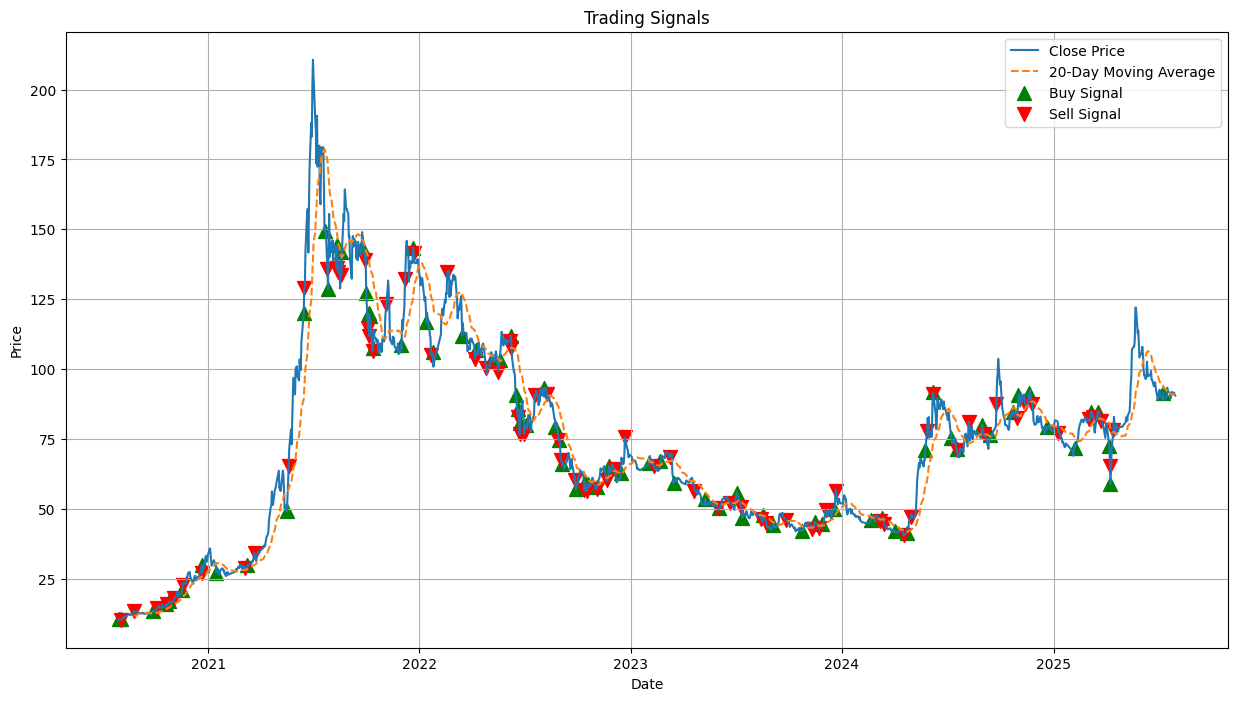

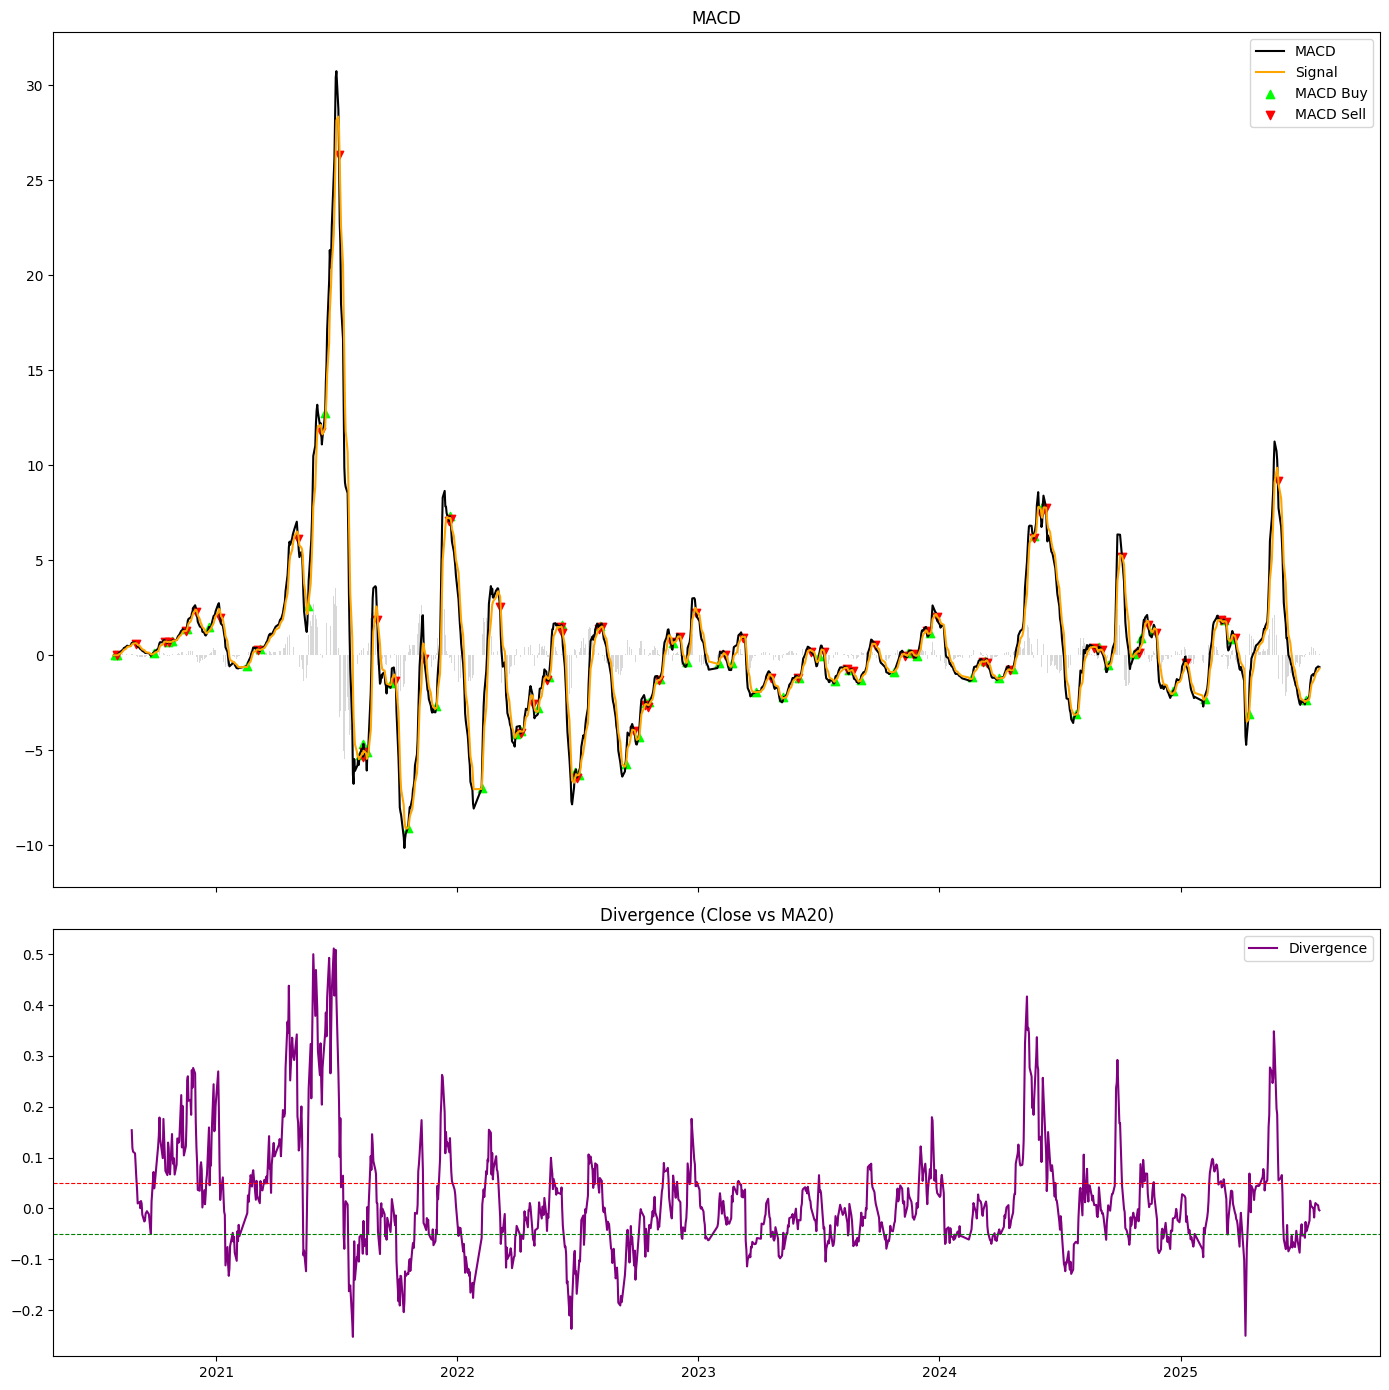

In [ ]:
# 第3版:無考慮 RSI，優化參數
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 參數設定
file_path = '/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx'     # 請改成你的檔案路徑
output_path = '/content/drive/MyDrive/交易程式碼/交易紀錄.xlsx'  # 回測結果匯出路徑
initial_capital = 1_000_000  # 初始資金
stop_loss = 0.05            # 停損門檻
take_profit = 0.30          # 停利門檻
buy_th = -0.10
sell_th = 0.10
fast_len = 9
slow_len = 21
macd_len = 5

# 2. 讀取 Excel 並處理時間欄位
df = pd.read_excel(file_path)
df['年月日'] = pd.to_datetime(df['年月日'])
df.sort_values('年月日', inplace=True)
df.set_index('年月日', inplace=True)

# 標準化欄位名稱
for col in df.columns:
    if '開盤' in col:
        df['Open'] = df[col]
    if '收盤' in col:
        df['Close'] = df[col]

# 3. 計算技術指標
# MACD
df['EMA_fast'] = df['Close'].ewm(span=fast_len, adjust=False).mean()
df['EMA_slow'] = df['Close'].ewm(span=slow_len, adjust=False).mean()
df['MACD'] = df['EMA_fast'] - df['EMA_slow']
df['MACD_signal'] = df['MACD'].ewm(span=macd_len, adjust=False).mean()
df['signal_macd_buy']  = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
df['signal_macd_sell'] = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))


# 布林通道 (Bollinger Bands)
window = 20
df['MA20']    = df['Close'].rolling(window).mean()
df['STD20']   = df['Close'].rolling(window).std()

# 乖離率 (Divergence)
df['divergence']      = (df['Close'] - df['MA20']) / df['MA20']
df['signal_dev_buy']  = df['divergence'] < buy_th
df['signal_dev_sell'] = df['divergence'] >  sell_th

# 4. 回測邏輯
cash = initial_capital
position = 0
entry_price = 0
trades = []

for date, row in df.iterrows():
    price = row['Close']
    # 買入條件：任何訊號為買
    if position == 0 and row[['signal_macd_buy','signal_dev_buy']].any():
        shares = cash // price
        if shares > 0:
            cost    = shares * price
            fee_buy = cost * 0.001425
            cash   -= (cost + fee_buy)
            position = shares
            entry_price = price
            trades.append({
                'action':'buy',
                'date': date,
                'price': price,
                'shares': shares,
                'fee_buy': fee_buy,
                'invested': cost + fee_buy,
                'cash_after': cash,
                'reason': 'MACD or Dev'
            })
    # 賣出條件：停損、停利或任何賣出訊號
    elif position > 0:
        pnl = (price - entry_price) / entry_price
        fee_sell = position * price * 0.001425
        tax      = position * price * 0.003
        if (pnl <= -stop_loss or pnl >= take_profit) or row[['signal_macd_sell','signal_dev_sell']].any():
            proceeds = position * price
            cash += (proceeds - fee_sell - tax)
            trades.append({
                'action':'sell',
                'date': date,
                'price': price,
                'shares': position,
                'fee_sell': fee_sell,
                'tax': tax,
                'proceeds': proceeds - fee_sell - tax,
                'return': pnl,
                'cash_after': cash
            })
            position = 0 # position = 0 → 空手（沒有部位）


# 5. 績效評估
trades_df = pd.DataFrame(trades)
if not trades_df.empty:
    final_value = cash + position * df['Close'].iloc[-1]
    total_return = final_value / initial_capital - 1
    days = (df.index[-1] - df.index[0]).days
    annual_return = (1 + total_return)**(365/days) - 1
    sell_returns = trades_df.query("action=='sell'")['return']
    win_rate = sell_returns.gt(0).mean()
    sharpe_ratio = sell_returns.mean() / sell_returns.std() * np.sqrt(252)
    print("===== 回測績效 =====")
    print(f"勝率:         {win_rate:.2%}")
    print(f"最終資產價值: NT${final_value:,.0f}")
    print(f"總報酬率:     {total_return:.2%}")
    print(f"年化報酬率:   {annual_return:.2%}")
    print(f"夏普比率:     {sharpe_ratio:.2f}")

# 6. 繪製交易訊號
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Close'], label='Close Price')
plt.plot(df.index, df['MA20'], label='20-Day Moving Average', linestyle='--')

# 標示買入點
buy_signals = trades_df[trades_df['action'] == 'buy']
plt.scatter(buy_signals['date'], buy_signals['price'], marker='^', color='green', label='Buy Signal', s=100)

# 標示賣出點
sell_signals = trades_df[trades_df['action'] == 'sell']
plt.scatter(sell_signals['date'], sell_signals['price'], marker='v', color='red', label='Sell Signal', s=100)

plt.title('Trading Signals')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

file_path = '/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx'     # 請改成你的檔案路徑
output_path = '/content/drive/MyDrive/交易程式碼/交易紀錄.xlsx'

fig, axes = plt.subplots(2, 1, figsize=(14, 14), sharex=True,
                         gridspec_kw={'height_ratios':[2,1,]})

# MACD
ax = axes[0]
ax.bar(df.index, df['MACD'] - df['MACD_signal'], color='grey', alpha=0.3)
ax.plot(df.index, df['MACD'],      color='black', label='MACD')
ax.plot(df.index, df['MACD_signal'],  color='orange', label='Signal')
ax.scatter(df.index[df['signal_macd_buy']],  df['MACD'][df['signal_macd_buy']],  marker='^', color='lime', label='MACD Buy')
ax.scatter(df.index[df['signal_macd_sell']], df['MACD'][df['signal_macd_sell']], marker='v', color='red',  label='MACD Sell')
ax.set_title('MACD')
ax.legend()

# 乖離率
ax = axes[1]
ax.plot(df.index, df['divergence'], color='purple', label='Divergence')
ax.axhline(0.05,  color='red',  ls='--', lw=0.8)
ax.axhline(-0.05, color='green',ls='--', lw=0.8)
ax.set_title('Divergence (Close vs MA20)')
ax.legend()


plt.tight_layout()
plt.show()

======== 交易統計 ========
完成交易次數（Buy+Sell）: 75
平均損益率          : 1.62%
交易紀錄已匯出至 /content/drive/MyDrive/交易程式碼/交易紀錄.xlsx


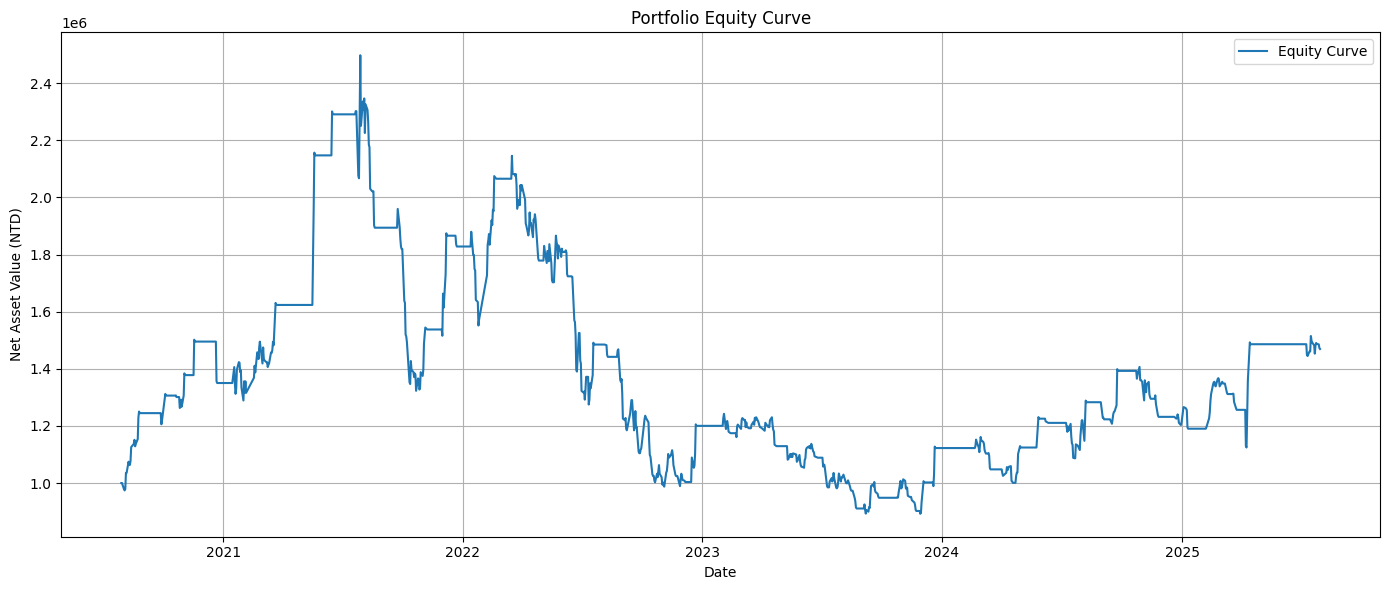

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 參數設定 -----------------------------------------------------------------
file_path   = '/content/drive/MyDrive/交易程式碼/萬海股價歷史數據.xlsx'    # ← 改成你的檔案路徑
output_path = '/content/drive/MyDrive/交易程式碼/交易紀錄.xlsx'           # ← 匯出路徑
initial_capital = 1_000_000     # 初始資金
stop_loss   = 0.05              # 停損門檻
take_profit = 0.30              # 停利門檻
buy_th      = -0.10
sell_th     = 0.10
fast_len    = 9
slow_len    = 21
macd_len    = 5

# 2. 讀取 & 前處理 ------------------------------------------------------------
df = pd.read_excel(file_path)
df['年月日'] = pd.to_datetime(df['年月日'])
df.sort_values('年月日', inplace=True)
df.set_index('年月日', inplace=True)

# 標準化欄位名稱
for col in df.columns:
    if '開盤' in col:  df['Open']  = df[col]
    if '收盤' in col:  df['Close'] = df[col]

# 3. 技術指標 -----------------------------------------------------------------
# MACD
df['EMA_fast']    = df['Close'].ewm(span=fast_len, adjust=False).mean()
df['EMA_slow']    = df['Close'].ewm(span=slow_len, adjust=False).mean()
df['MACD']        = df['EMA_fast'] - df['EMA_slow']
df['MACD_signal'] = df['MACD'].ewm(span=macd_len, adjust=False).mean()
df['signal_macd_buy']  = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
df['signal_macd_sell'] = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))

# 布林通道 + 乖離率
window = 20
df['MA20']      = df['Close'].rolling(window).mean()
df['STD20']     = df['Close'].rolling(window).std()
df['divergence']      = (df['Close'] - df['MA20']) / df['MA20']
df['signal_dev_buy']  = df['divergence'] < buy_th
df['signal_dev_sell'] = df['divergence'] > sell_th

# 4. 回測主迴圈 ---------------------------------------------------------------
cash = initial_capital
position = 0
entry_price = 0
trades = []            # 原始買 / 賣動作
equity_curve = []      # === NEW === 用來存每天的資產淨值

for date, row in df.iterrows():
    price = row['Close']
    # 先記錄「當下」資產淨值
    equity_curve.append({'date': date, 'equity': cash + position * price})  # === NEW ===

    # ─── 買入 ───
    if position == 0 and row[['signal_macd_buy', 'signal_dev_buy']].any():
        shares = cash // price
        if shares > 0:
            cost     = shares * price
            fee_buy  = cost * 0.001425
            cash    -= (cost + fee_buy)
            position = shares
            entry_price = price
            trades.append({
                'action':'buy', 'date': date, 'price': price, 'shares': shares,
                'fee': fee_buy, 'cash_after': cash, 'reason': 'MACD or Dev'
            })

    # ─── 賣出 ───
    elif position > 0:
        pnl = (price - entry_price) / entry_price
        fee_sell = position * price * 0.001425
        tax      = position * price * 0.003
        if (pnl <= -stop_loss or pnl >= take_profit) or row[['signal_macd_sell','signal_dev_sell']].any():
            proceeds = position * price
            cash += (proceeds - fee_sell - tax)
            trades.append({
                'action':'sell', 'date': date, 'price': price, 'shares': position,
                'fee': fee_sell + tax, 'pnl%': pnl, 'cash_after': cash
            })
            position = 0   # 平倉

# 5. 將原始動作轉成「一次交易」記錄 ------------------------------------------
trades_df = pd.DataFrame(trades)

# === NEW === 把 buy / sell 配對
completed = []
current   = {}
for _, row in trades_df.iterrows():
    if row['action'] == 'buy':
        current = row.to_dict()
    else:  # sell
        completed.append({
            'buy_date' : current['date'],
            'buy_price': current['price'],
            'sell_date': row['date'],
            'sell_price': row['price'],
            'shares'   : row['shares'],
            'holding_days': (row['date'] - current['date']).days,
            'pnl%'     : row['pnl%']
        })
        current = {}
completed_df = pd.DataFrame(completed)
total_trades = len(completed_df)   # 一買一賣才算一次

print(f'======== 交易統計 ========')
print(f'完成交易次數（Buy+Sell）: {total_trades}')
if not completed_df.empty:
    print(f'平均損益率          : {completed_df["pnl%"].mean():.2%}')

# 6. 產出 Excel ---------------------------------------------------------------
# === NEW === 兩個工作表：RawActions 與 CompletedTrades
with pd.ExcelWriter(output_path) as writer:
    trades_df.to_excel(writer,    sheet_name='RawActions',      index=False)
    completed_df.to_excel(writer, sheet_name='CompletedTrades', index=False)
print(f'交易紀錄已匯出至 {output_path}')

# 7. 繪製資產淨值變化曲線 ------------------------------------------------------
equity_df = pd.DataFrame(equity_curve).set_index('date')
plt.figure(figsize=(14,6))
plt.plot(equity_df.index, equity_df['equity'], label='Equity Curve')
plt.title('Portfolio Equity Curve')               # === NEW === Title
plt.xlabel('Date')
plt.ylabel('Net Asset Value (NTD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. （選擇性）若仍想看買賣點，可沿用舊版 plot -----------------------------
# 若要顯示買賣點，可把原本的「Close + MA20 + Buy/Sell scatter」區塊保留


In [ ]:
trades_df.to_csv("/content/drive/MyDrive/交易程式碼/2025萬海回測結果第三版交易紀錄.csv")